In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns


In [2]:
df = pd.read_csv("netflix data.csv",engine="python")

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


### Clean Data sets 

In [5]:

df.isnull().sum()


Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df=df.dropna().copy()

In [8]:
df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

### Change Data Types

In [9]:
df["Release_Date"]=pd.to_datetime(df["Release_Date"])
df["Vote_Count"] = df["Vote_Count"].astype(int)
df["Vote_Average"] = df["Vote_Average"].astype(float)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9826 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9826 non-null   datetime64[ns]
 1   Title              9826 non-null   object        
 2   Overview           9826 non-null   object        
 3   Popularity         9826 non-null   float64       
 4   Vote_Count         9826 non-null   int64         
 5   Vote_Average       9826 non-null   float64       
 6   Original_Language  9826 non-null   object        
 7   Genre              9826 non-null   object        
 8   Poster_Url         9826 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 767.7+ KB


In [11]:
df['Release_Date']=df['Release_Date'].dt.year

In [12]:
df.head()


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [13]:
 #remove unwanted colomn :

In [14]:
cols = ["Overview","Original_Language","Poster_Url"]

In [15]:
df.drop(cols , axis=1,inplace=True)

In [16]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [17]:
def categories_colm(df, col , labels):
    desc = df[col].describe()

    edges = [
        desc["min"],
        desc["25%"],
        desc["50%"],
        desc["75%"],
        desc["max"],
    ]

    df[col] = pd.cut(
        df[col],
        bins=edges,
        labels=labels,
        duplicates='drop',
       
    )

    return df




In [18]:
labels = ['not_popular', 'below_avg', 'average', 'popular']

df = categories_colm(df, 'Vote_Average', labels)
df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [19]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [20]:

df["Vote_Average"].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2411
below_avg      2398
Name: count, dtype: int64

In [21]:
df.isnull().sum()

Release_Date      0
Title             0
Popularity        0
Vote_Count        0
Vote_Average    100
Genre             0
dtype: int64

In [22]:
df.dropna(inplace=True)

In [23]:
df.isnull().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [24]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


### We split Genre section into list 

In [25]:
df["Genre"]=df["Genre"].str.split(", ")
df=df.explode("Genre").reset_index(drop= True)

In [26]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [27]:
df["Genre"]=df["Genre"].astype("category")

In [28]:
df["Genre"].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [29]:
df.nunique()

Release_Date     100
Title           9414
Popularity      8087
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

## DATA VISUALIZATION 

### Q1: What is the most frequent genre of movie  released  on Netflix ?

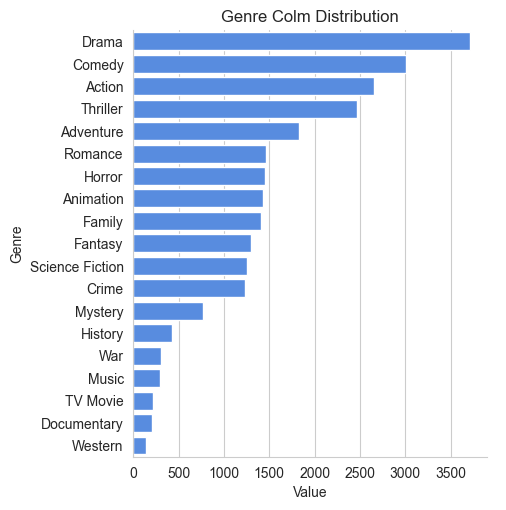

In [30]:
import seaborn as sns
sns.set_style("whitegrid")
sns.catplot(y='Genre',data=df,kind="count",
            order=df['Genre'].value_counts().index,
            color="#4287f5"
           )
plt.title("Genre Colm Distribution")
plt.ylabel("Genre")
plt.xlabel("Value")
plt.show()

### Q2: Which Is the hightest vote in the vote colmn ?

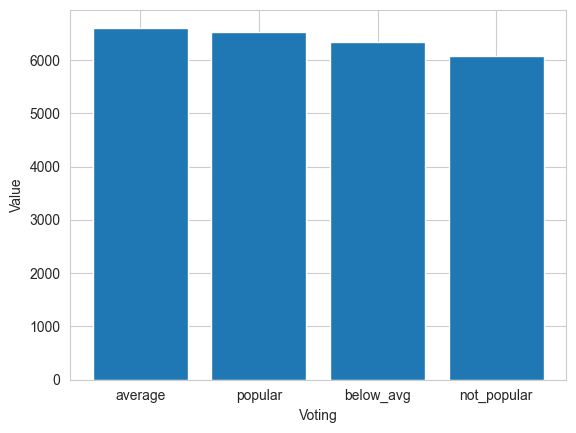

In [31]:
High_Vote=df["Vote_Average"].value_counts()
plt.bar(High_Vote.index ,High_Vote.values)
plt.ylabel("Value")
plt.xlabel("Voting")
plt.show()



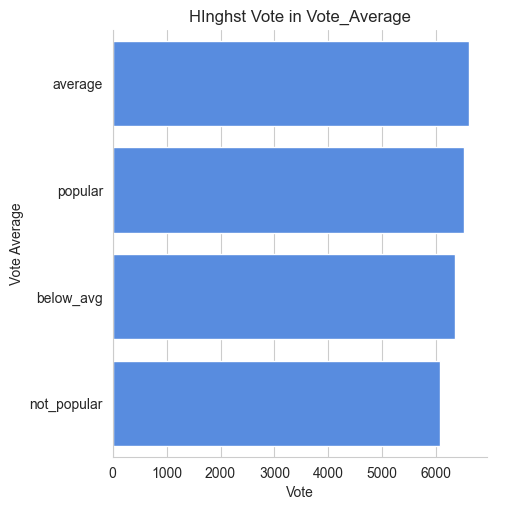

In [32]:
sns.set_style("whitegrid")
sns.catplot(y='Vote_Average',data=df,kind="count",
            order=df['Vote_Average'].value_counts().index,
            color="#4287f5"
           )
plt.title("HInghst Vote in Vote_Average")
plt.ylabel("Vote Average")
plt.xlabel("Vote")
plt.show()

### What's genre got Highest poplarity  ?

In [33]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


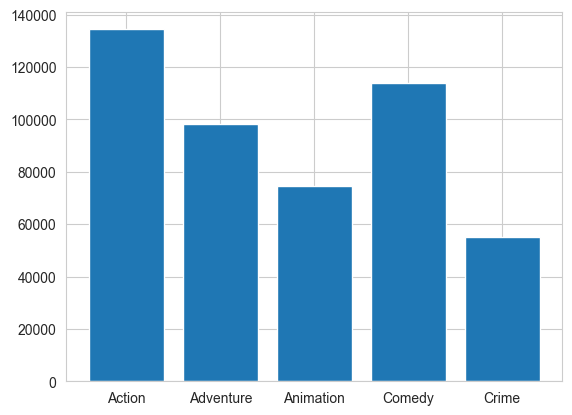

In [34]:
hpm = df.groupby("Genre", observed=True)["Popularity"].sum().head()
plt.bar(hpm.index,hpm.values)
plt.show()


### What's Movies got Highest poplarity and what is genre  ?

In [36]:
df[df["Popularity"]==df["Popularity"].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


### What's Movies got Lowest poplarity and what is genre  ?

In [37]:
df[df["Popularity"]==df["Popularity"].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25545,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25547,2021,The United States vs. Billie Holiday,13.354,152,average,History
25548,1984,Threads,13.354,186,popular,War
25549,1984,Threads,13.354,186,popular,Drama
25550,1984,Threads,13.354,186,popular,Science Fiction


### Which years has most fillemd movie ?


In [43]:
top_years=df["Release_Date"].value_counts().head()

Release_Date
2021    1636
2018    1384
2017    1365
2019    1271
2016    1209
Name: count, dtype: int64

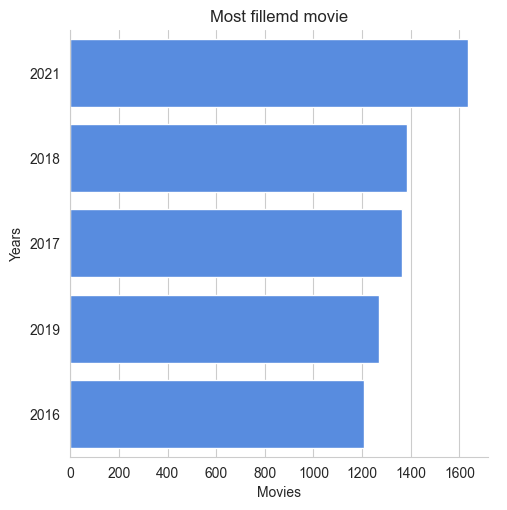

In [49]:
import seaborn as sns
sns.set_style("whitegrid")
sns.catplot(y='Release_Date',data=df,kind="count",
            order=df['Release_Date'].value_counts().head().index,
            
            color="#4287f5"
           )
plt.title("Most fillemd movie")
plt.ylabel("Years")
plt.xlabel("Movies")
plt.show()

### 2nd Method

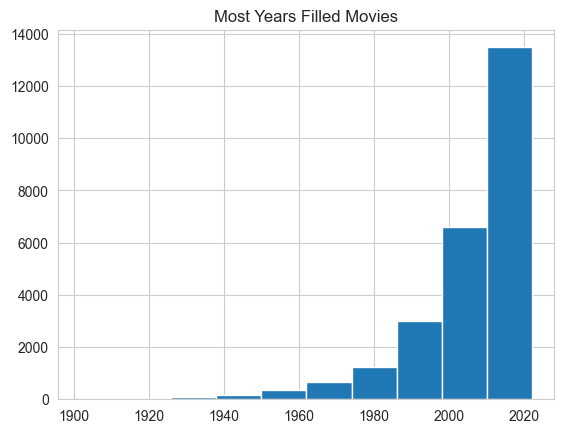

In [50]:
df["Release_Date"].hist()
plt.title("Most Years Filled Movies")
plt.show()



Conclusion:

Q1: What is the most frequent genre in the dataset?
A: Drama is the most frequent genre in the dataset, contributing to more than 14% of the total content among all genres.

Q2: Which genre has the highest votes?
A: Drama genre has the highest number of votes, covering approximately 25.5% of the dataset, indicating strong audience engagement.

Q3: What movie has the highest popularity and what is its genre?
A: "Spider-Man: No Way Home" has the highest popularity in the dataset. It belongs to multiple genres including Action, Adventure, and Science Fiction.

Q4: What movie has the lowest popularity and what is its genre?
A: "The United States, Thread" has the lowest popularity in the dataset. It includes genres such as Music, Drama, War, Sci-Fi, and History.

Q5: Which year has the highest number of movies released?
A: The year 2020 has the highest number of movie releases in the dataset.

Overall, the analysis shows that Drama is the most dominant genre, and multi-genre movies, especially Action and Sci-Fi, tend to achieve higher popularity.
